**This program aims to predict future energy usage using a publicly available dataset**

In this case, the data has already been split into training & test data

**Load & Analyse Data**

Using pandas, load the data & inspect the first few rows

In [1]:
import pandas as pd

# Training data
train_df = pd.read_csv("train.csv")
print("Training data")
print(train_df.head())

# Test data
test_df = pd.read_csv("test.csv")
print("\nTest data")
print(test_df.head())


Training data
         date  power_consumption  year  ...  week_in_year  day_in_year month
0  12/16/2006           1209.176  2006  ...            50          350    12
1  12/17/2006           3390.460  2006  ...            51          351    12
2  12/18/2006           2203.826  2006  ...            51          352    12
3  12/19/2006           1666.194  2006  ...            51          353    12
4  12/20/2006           2225.748  2006  ...            51          354    12

[5 rows x 9 columns]

Test data
       date  power_consumption  year  ...  week_in_year  day_in_year month
0  4/1/2010           1687.440  2010  ...            13           91     4
1  4/2/2010           1648.622  2010  ...            14           92     4
2  4/3/2010           1805.278  2010  ...            14           93     4
3  4/4/2010           1690.388  2010  ...            14           94     4
4  4/5/2010           1118.820  2010  ...            14           95     4

[5 rows x 9 columns]


Check for any missing values

In [2]:
# Training data
print("Missing values in training data")
print(train_df.isnull().sum())

# Test data
print("\nMissing values in test data")
print(test_df.isnull().sum())

Missing values in training data
date                 0
power_consumption    0
year                 0
semester             0
quarter              0
day_in_week          0
week_in_year         0
day_in_year          0
month                0
dtype: int64

Missing values in test data
date                 0
power_consumption    0
year                 0
semester             0
quarter              0
day_in_week          0
week_in_year         0
day_in_year          0
month                0
dtype: int64


**Data Preparation**
Check the data types of each column

In [3]:
# Training data
print("Training data types")
print(train_df.dtypes)

# Test data
print("\nTest data types")
print(test_df.dtypes)

Training data types
date                  object
power_consumption    float64
year                   int64
semester               int64
quarter                int64
day_in_week           object
week_in_year           int64
day_in_year            int64
month                  int64
dtype: object

Test data types
date                  object
power_consumption    float64
year                   int64
semester               int64
quarter                int64
day_in_week           object
week_in_year           int64
day_in_year            int64
month                  int64
dtype: object


Convert *date* into a usable format

In [4]:
# Training data
train_df["date"] = pd.to_datetime(train_df["date"], format="%m/%d/%Y")
print("Training date format updated")
print(train_df.head())

# Test data
test_df["date"] = pd.to_datetime(test_df["date"], format="%m/%d/%Y")
print("\nTest date format updated")
print(test_df.head())

Training date format updated
        date  power_consumption  year  ...  week_in_year  day_in_year month
0 2006-12-16           1209.176  2006  ...            50          350    12
1 2006-12-17           3390.460  2006  ...            51          351    12
2 2006-12-18           2203.826  2006  ...            51          352    12
3 2006-12-19           1666.194  2006  ...            51          353    12
4 2006-12-20           2225.748  2006  ...            51          354    12

[5 rows x 9 columns]

Test date format updated
        date  power_consumption  year  ...  week_in_year  day_in_year month
0 2010-04-01           1687.440  2010  ...            13           91     4
1 2010-04-02           1648.622  2010  ...            14           92     4
2 2010-04-03           1805.278  2010  ...            14           93     4
3 2010-04-04           1690.388  2010  ...            14           94     4
4 2010-04-05           1118.820  2010  ...            14           95     4

[5 rows x 

Convert *day_in_week* into a usable format (where 0 is Monday, 6 is Sunday) using numpy dt

In [5]:
# Training data
train_df["day_in_week"] = train_df["date"].dt.dayofweek
print("Training day in week format updated")
print(train_df.head())

# Test data
test_df["day_in_week"] = test_df["date"].dt.dayofweek
print("\nTest day of week format updated")
print(test_df.head())

Training day in week format updated
        date  power_consumption  year  ...  week_in_year  day_in_year  month
0 2006-12-16           1209.176  2006  ...            50          350     12
1 2006-12-17           3390.460  2006  ...            51          351     12
2 2006-12-18           2203.826  2006  ...            51          352     12
3 2006-12-19           1666.194  2006  ...            51          353     12
4 2006-12-20           2225.748  2006  ...            51          354     12

[5 rows x 9 columns]

Test day of week format updated
        date  power_consumption  year  ...  week_in_year  day_in_year  month
0 2010-04-01           1687.440  2010  ...            13           91      4
1 2010-04-02           1648.622  2010  ...            14           92      4
2 2010-04-03           1805.278  2010  ...            14           93      4
3 2010-04-04           1690.388  2010  ...            14           94      4
4 2010-04-05           1118.820  2010  ...            14      

In [6]:
print(train_df.dtypes)
print(test_df.dtypes)

date                 datetime64[ns]
power_consumption           float64
year                          int64
semester                      int64
quarter                       int64
day_in_week                   int32
week_in_year                  int64
day_in_year                   int64
month                         int64
dtype: object
date                 datetime64[ns]
power_consumption           float64
year                          int64
semester                      int64
quarter                       int64
day_in_week                   int32
week_in_year                  int64
day_in_year                   int64
month                         int64
dtype: object


Cyclically encode *day in week* to avoid models inferring incorrect relationships (i.e. make sure it recognises Monday is after Sunday and the cycle continues)

In [7]:
import numpy as np

# Ensure values are numeric
train_df["day_in_week"] = pd.to_numeric(train_df["day_in_week"])
test_df["day_in_week"] = pd.to_numeric(test_df["day_in_week"])

# Training data
train_df["day_in_week_sin"] = np.sin(2 * np.pi * train_df["day_in_week"] / 7)
train_df["day_in_week_cos"] = np.cos(2 * np.pi * train_df["day_in_week"] / 7)

# Test data
test_df["day_in_week_sin"] = np.sin(2 * np.pi * test_df["day_in_week"] / 7)
test_df["day_in_week_cos"] = np.cos(2 * np.pi * test_df["day_in_week"] / 7)

# drop the original day_in_week column
train_df = train_df.drop(columns=["day_in_week"])
test_df = test_df.drop(columns=["day_in_week"])

print(train_df.head())
print(test_df.head())

        date  power_consumption  year  ...  month  day_in_week_sin  day_in_week_cos
0 2006-12-16           1209.176  2006  ...     12        -0.974928        -0.222521
1 2006-12-17           3390.460  2006  ...     12        -0.781831         0.623490
2 2006-12-18           2203.826  2006  ...     12         0.000000         1.000000
3 2006-12-19           1666.194  2006  ...     12         0.781831         0.623490
4 2006-12-20           2225.748  2006  ...     12         0.974928        -0.222521

[5 rows x 10 columns]
        date  power_consumption  year  ...  month  day_in_week_sin  day_in_week_cos
0 2010-04-01           1687.440  2010  ...      4         0.433884        -0.900969
1 2010-04-02           1648.622  2010  ...      4        -0.433884        -0.900969
2 2010-04-03           1805.278  2010  ...      4        -0.974928        -0.222521
3 2010-04-04           1690.388  2010  ...      4        -0.781831         0.623490
4 2010-04-05           1118.820  2010  ...      4    

Do the same for the 'month' data

In [8]:
# Training data
train_df["month_sin"] = np.sin(2 * np.pi * train_df["month"] / 12)
train_df["month_cos"] = np.cos(2 * np.pi * train_df["month"] / 12)

# Test data
test_df["month_sin"] = np.sin(2 * np.pi * test_df["month"] / 12)
test_df["month_cos"] = np.cos(2 * np.pi * test_df["month"] / 12)

# Remove the original month column
train_df.drop("month", axis=1, inplace=True)
test_df.drop("month", axis=1, inplace=True)

# Print updated data
print(train_df.head())
print(test_df.head())

        date  power_consumption  year  ...  day_in_week_cos     month_sin  month_cos
0 2006-12-16           1209.176  2006  ...        -0.222521 -2.449294e-16        1.0
1 2006-12-17           3390.460  2006  ...         0.623490 -2.449294e-16        1.0
2 2006-12-18           2203.826  2006  ...         1.000000 -2.449294e-16        1.0
3 2006-12-19           1666.194  2006  ...         0.623490 -2.449294e-16        1.0
4 2006-12-20           2225.748  2006  ...        -0.222521 -2.449294e-16        1.0

[5 rows x 11 columns]
        date  power_consumption  year  ...  day_in_week_cos  month_sin  month_cos
0 2010-04-01           1687.440  2010  ...        -0.900969   0.866025       -0.5
1 2010-04-02           1648.622  2010  ...        -0.900969   0.866025       -0.5
2 2010-04-03           1805.278  2010  ...        -0.222521   0.866025       -0.5
3 2010-04-04           1690.388  2010  ...         0.623490   0.866025       -0.5
4 2010-04-05           1118.820  2010  ...         1.0000

Train a linear regression model

In [9]:
from sklearn.linear_model import LinearRegression

# define the features (x) and target variable (y)
# drop the date column too, as scikit learn models don't like objects
x_train = train_df.drop(columns=["power_consumption", "date"])
y_train = train_df["power_consumption"]

x_test = test_df.drop(columns=["power_consumption", "date"])
y_test = test_df["power_consumption"]
print("Feature and target definition completed")



# train the model
model = LinearRegression()
model.fit(x_train, y_train)
print("Model training completed")

Feature and target definition completed
Model training completed


Test the model and evaluate performance

Model testing completed
Mean Squared Error: 170244.31
Mean Absolute Error: 322.69
Root Mean Squared Error: 412.61
R-squared: 0.27


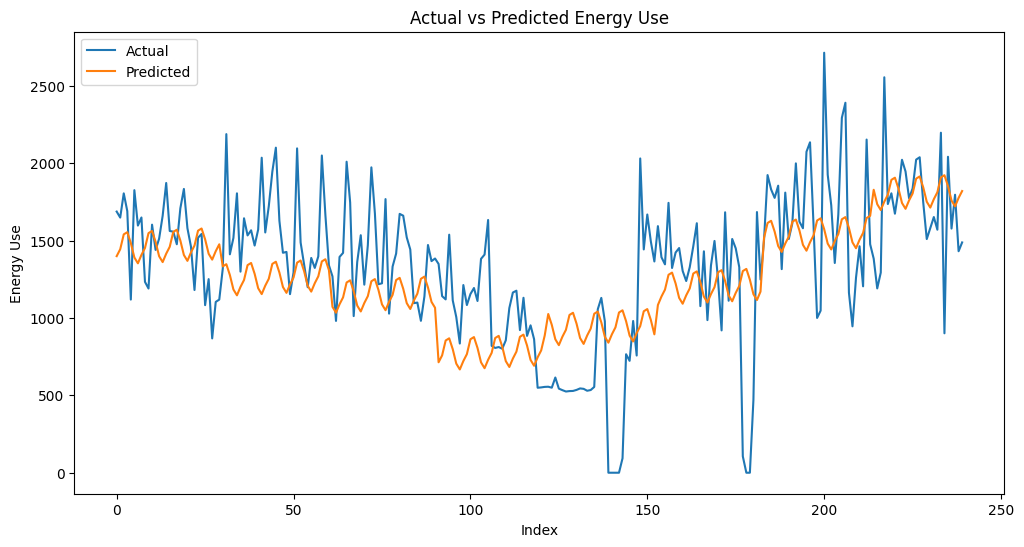

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Test the model
y_pred = model.predict(x_test)
print("Linear Regression model testing completed")

# Evaluate the results using mean MSE, MAE and RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Linear Regression Mean Squared Error: {mse:.2f}")
print(f"Linear Regression Mean Absolute Error: {mae:.2f}")
print(f"Linear Regression Root Mean Squared Error: {rmse:.2f}")
print(f"Linear Regression R-squared: {r2:.2f}")

# Visualise the results
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
results_df = results_df.reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x=results_df.index, y="Actual", label="Actual")
sns.lineplot(data=results_df, x=results_df.index, y="Predicted", label="Predicted")
plt.xlabel("Index")
plt.ylabel("Energy Use")
plt.title("Linear Regression - Actual vs Predicted Energy Use")
plt.legend()
plt.show()

An r2 score of 0.27 indicates the model does not perform particularly well.  This could be because the relationships between the features are less linear/more subtle.

Incorporating a Random Forest model, for comparison

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
print("Random Forest model training completed")

y_rf_pred = rf_model.predict(x_test)
print("Random Forest model testing completed")

rf_mse = mean_squared_error(y_test, y_rf_pred)
rf_mae = mean_absolute_error(y_test, y_rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_rf_pred)

print(f"Random Forest Mean Squared Error: {rf_mse:.2f}")
print(f"Random Forest Mean Absolute Error: {rf_mae:.2f}")
print(f"Random Forest Root Mean Squared Error: {rf_rmse:.2f}")
print(f"Random Forest R-squared: {rf_r2:.2f}")

rf_results_df = pd.DataFrame({"Actual": y_test, "Predicted": y_rf_pred})
rf_results_df = rf_results_df.reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=rf_results_df, x=rf_results_df.index, y="Actual", label="Actual")
sns.lineplot(data=rf_results_df, x=rf_results_df.index, y="Predicted", label="Predicted")
plt.xlabel("Index")
plt.ylabel("Energy Use")
plt.title("Random Forest Actual vs Predicted Energy Use")
plt.legend()
plt.show()